# Code from scratch

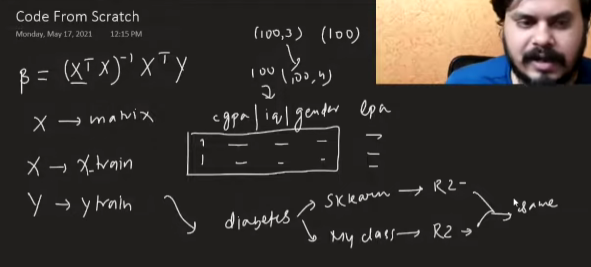

In [1]:
import numpy as np
from sklearn.datasets import load_diabetes

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [4]:
X.shape

(442, 10)

In [5]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [25]:
y.shape

(442,)

## Using Sklearn's Linear Regression

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
reg = LinearRegression()

In [11]:
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = reg.predict(X_test)

In [13]:
from sklearn.metrics import r2_score

In [14]:
r2_score(y_test,y_pred)

0.439933866156897

In [15]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [16]:
reg.intercept_

np.float64(151.88331005254167)

## Making our own Linear Regression Class

In [17]:
class MeraLR:
    
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        
        # calcuate the coeffs
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
    
    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred
        
    

In [18]:
lr = MeraLR()

In [19]:
lr.fit(X_train,y_train)

In [20]:
X_train.shape

(353, 10)

In [ ]:
# np.insert(arr, obj, values, axis)

# Insert a column of 1s at the beginning (index 0) of X_train
X_train = np.insert(X_train, 0, 1, axis=1)

# Explanation:
# X_train → original 2D feature matrix of shape (n_samples, n_features)
# 0       → index where insertion happens (column 0 → beginning)
# 1       → value to insert (broadcasted as a full column of 1s)
# axis=1  → insert along columns (axis=0 would insert rows)

# Result:
# Shape becomes (n_samples, n_features + 1)
# First column = all 1s (used as bias/intercept term in ML models)

array([[ 1.        , -0.00188202, -0.04464164, ..., -0.03949338,
        -0.06291688,  0.04034337],
       [ 1.        , -0.00914709, -0.04464164, ..., -0.03949338,
         0.01703607, -0.0052198 ],
       [ 1.        ,  0.02354575,  0.05068012, ..., -0.03949338,
        -0.09643495, -0.01764613],
       ...,
       [ 1.        ,  0.06350368,  0.05068012, ..., -0.00259226,
         0.08449153, -0.01764613],
       [ 1.        , -0.05273755,  0.05068012, ...,  0.1081111 ,
         0.03606033, -0.04249877],
       [ 1.        ,  0.00175052,  0.05068012, ...,  0.1081111 ,
         0.06898589,  0.12732762]], shape=(353, 11))

In [21]:
np.insert(X_train,0,1,axis=1).shape

(353, 11)

In [22]:
y_pred = lr.predict(X_test)

In [23]:
r2_score(y_test,y_pred)

0.4399338661568961

In [24]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [25]:
lr.intercept_

np.float64(151.8833100525417)